# Flat Weight-Shared Parallel QCNN Pipeline (CIFAR-10) — v4

**v4 replaces the v3 hierarchical-reduction architecture with a much flatter
one, per the updated whiteboard spec.** The two structural elements v3 had
are both removed:

1. The **classical skip connection** (v3 concatenated a 16-d global-average-pooled
   CNN feature vector alongside the 4 quantum outputs before the classifier head).
2. The **binary-tree reduction across the 64 partitions** (v3 combined
   neighbouring partitions' density matrices via `batched_kron` and ran a
   shared conv+pool block at every tree level, 64 -> 32 -> ... -> 1).

## New architecture

```
CIFAR-10 image (3x32x32)
        |
        v
   Classical CNN (unchanged: conv3->8 -> pool -> conv8->16 -> pool)
        |
        v
    16 x 8 x 8  ->  reshape  ->  64 vectors x 16 dims
        |
        |  (SAME quantum circuit + SAME trainable params for all 64 vectors,
        |   run as ONE broadcasted PennyLane call, not a Python loop)
        v
  16 -> split into two 8-dim chunks -> re-upload both chunks onto an
  8-qubit register -> 2-layer QCNN convolution (weight-shared) -> pooling
  8 qubits -> 4 qubits -> immediately measure <Z> on all 4 kept qubits
        |
        v
   4 real numbers per vector  x  64 vectors  =  256 real numbers per image
        |
        v
      Linear(256 -> 10)
        |
        v
      Softmax (log_softmax + NLL loss)
        |
        v
   CIFAR-10 class
```

There is **no interaction between the 64 vectors at any point** -- each one
is processed by an identical, independent copy of the same 8-qubit circuit,
and all 64 copies share exactly the same `nn.Parameter`s (so the parameter
count does not scale with 64). This matches the target parameter budget
exactly: CNN 1,368 + quantum 44 (16 re-upload + 24 conv + 4 pool) +
classifier 2,570 = **3,982 total trainable parameters** -- verified in
Sec. 5 below.

`BATCH_SIZE = 32`, and the optimizer step happens once per batch (standard
PyTorch `forward -> loss -> backward -> opt.step()` per batch), matching the
requested update rule.

## 1. Setup

In [1]:
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml
from torch.utils.data import DataLoader

torch.manual_seed(0)
np.random.seed(0)

DEVICE = "cpu"   # the quantum QNode below is CPU-only (default.qubit); the
                  # classical CNN/Linear layers would happily move to GPU, but
                  # keeping everything on one device avoids host<->device
                  # transfer overhead on every batch given how small the
                  # tensors are.
print("torch:", torch.__version__, "| pennylane:", qml.__version__, "| device:", DEVICE)


torch: 2.5.1+cu121 | pennylane: 0.44.1 | device: cpu


## 2. CNN feature extractor (unchanged from v3)

Same two-conv-layer front end (`8ch` then `16ch`): `32x32x3 -> 16x16x8 -> 8x8x16`,
reshaped to 64 partitions of 16 dims each. **No `feat_map` is returned any more**
-- v3 kept it around for the classical skip connection, which v4 removes.

In [2]:
class CNNFeatureExtractor(nn.Module):
    '''2-conv-layer front end:
    32x32x3 -> conv(8ch) -> ReLU -> maxpool(2x2) -> 16x16x8
             -> conv(16ch) -> ReLU -> maxpool(2x2) -> 8x8x16
             -> reshape -> 64 partitions x 16 dims
    '''
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3,  8, kernel_size=3, stride=1, padding=1, bias=False)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.pool  = nn.MaxPool2d(2, 2)

    def forward(self, x):                        # (B, 3, 32, 32)
        x = self.pool(F.relu(self.conv1(x)))      # (B, 8, 16, 16)
        x = self.pool(F.relu(self.conv2(x)))      # (B, 16, 8, 8)
        x = x.permute(0, 2, 3, 1)                 # (B, 8, 8, 16)
        x = x.reshape(x.shape[0], 64, 16)         # (B, 64, 16) -- 64 partitions of 16 dims
        return x

cnn = CNNFeatureExtractor()
print(f"classical CNN params: {sum(p.numel() for p in cnn.parameters()):,}")

with torch.no_grad():
    dummy = torch.randn(2, 3, 32, 32)
    feat = cnn(dummy)
    print("partition tensor shape:", feat.shape, " (batch, 64 partitions, 16 dims each)")


classical CNN params: 1,368
partition tensor shape: torch.Size([2, 64, 16])  (batch, 64 partitions, 16 dims each)


## 3. Quantum building blocks

`reupload_two_chunks` and `qcnn_layer` are unchanged from v3: the same
re-uploading encoding (Hadamard + data-`RY` per chunk, CNOT ring, trainable
`CRY` ring) and the same 3-gate-per-pair convolution + `CRY` pooling. The
difference from v3 is entirely in **how these are wired together afterwards**
-- v3 fed the output into a reduction tree of *further* QNode calls; v4 stops
right here and measures.

In [3]:
N_REG      = 8      # register each partition's two chunks reupload onto
SINK       = 4       # qubits kept after the single conv+pool step (8 -> 4)
CONV_DEPTH = 2        # 2-layer QCNN, per spec

def reupload_two_chunks(chunk1, chunk2, wires, ent_weights):
    '''Reupload chunk1, entangle (CNOT ring + trainable CRY ring), then
    reupload chunk2 onto the SAME register and entangle again. `ent_weights`
    has shape (2, len(wires)) -- one CRY-ring row per chunk.'''
    n = len(wires)
    for r, chunk in enumerate((chunk1, chunk2)):
        for i, w in enumerate(wires):
            qml.Hadamard(wires=w)
            qml.RY((math.pi / 4) * chunk[..., i], wires=w)
        for i in range(n):                                    # CNOT ring
            qml.CNOT(wires=[wires[i], wires[(i + 1) % n]])
        for i in range(n):                                    # trainable CRY ring
            qml.CRY(ent_weights[r, i], wires=[wires[i], wires[(i + 1) % n]])


def qcnn_layer(wires, conv_w, pool_w, depth=CONV_DEPTH, pool=True):
    '''One QCNN block: `depth` rounds of parameterised 2-qubit convolution,
    then a controlled-rotation pooling step that keeps one qubit per pair
    and drops the other (8 -> 4 here).'''
    n = len(wires)
    npairs = n // 2
    for layer in range(depth):
        w_offset = layer * npairs
        for idx in range(npairs):
            a, b = wires[2 * idx], wires[2 * idx + 1]
            qml.RY(conv_w[w_offset + idx, 0], wires=a)
            qml.RY(conv_w[w_offset + idx, 1], wires=b)
            qml.CNOT(wires=[a, b])
            qml.RZ(conv_w[w_offset + idx, 2], wires=b)
            qml.CNOT(wires=[a, b])
    if not pool:
        return list(wires), []
    kept, dropped = [], []
    for idx in range(npairs):
        a, b = wires[2 * idx], wires[2 * idx + 1]
        qml.CRY(pool_w[idx], wires=[b, a])     # controlled-pool: b folds into a
        kept.append(a)
        dropped.append(b)
    if n % 2 == 1:
        kept.append(wires[-1])                  # carry an odd leftover through untouched
    return kept, dropped


## 4. The single QNode: re-upload -> 2-layer QCNN -> pool -> measure

This is the entire quantum branch now. **One** `default.qubit` QNode,
`backprop`-differentiated, broadcasts natively over its leading batch
dimension -- so calling it once with all `batch_size * 64` partition-vectors
stacked together runs (and backpropagates through) all of them in a single
call. There is no Python-level loop over the 64 partitions and no per-call
QNode overhead, and -- because it is a *statevector* (`default.qubit`) call
returning `PauliZ` expectation values directly, not a density matrix -- v3's
entire reduction-tree machinery (`default.mixed`, `batched_kron`,
partial-trace einsums, the vectorized-torch fallback) is gone; it's simply
not needed any more.

In [4]:
dev_local = qml.device("default.qubit", wires=N_REG)

@qml.qnode(dev_local, interface="torch", diff_method="backprop")
def local_block_measure(chunk1, chunk2, ent, conv_l, pool_l):
    '''Broadcasts over batch_size * 64 partitions at once. Returns the 4
    <Z> expectation values on the kept (post-pool) qubits -- i.e. the 4 real
    numbers per partition described in the spec.'''
    wires = list(range(N_REG))
    reupload_two_chunks(chunk1, chunk2, wires, ent)
    kept, _ = qcnn_layer(wires, conv_l, pool_l, pool=True)     # 8 -> 4
    return [qml.expval(qml.PauliZ(w)) for w in kept]


## 5. `QuantumParallelBlock`: apply the same circuit to all 64 partitions

Holds the **one** set of trainable weights (`ent`, `conv_l`, `pool_l`) shared
across every one of the 64 vectors -- exactly the "SAME PARAMETERS" weight-sharing
in the spec. `forward` flattens `(B, 64, 16)` to `(B*64, 16)`, splits each
16-d vector into its two 8-d chunks, and makes **one** broadcasted call to
`local_block_measure` for the whole batch.

In [5]:
class QuantumParallelBlock(nn.Module):
    def __init__(self, n_partitions=64):
        super().__init__()
        self.n_partitions = n_partitions
        self.ent    = nn.Parameter(0.1 * torch.randn(2, N_REG))          # 2*8  = 16 params
        self.conv_l = nn.Parameter(0.1 * torch.randn(CONV_DEPTH * 4, 3))  # 2*4*3 = 24 params
        self.pool_l = nn.Parameter(0.1 * torch.randn(4))                  #        4 params

    def forward(self, vectors):                       # (B, 64, 16)
        B, V, _ = vectors.shape
        assert V == self.n_partitions
        flat = vectors.reshape(B * V, 16)
        chunk1, chunk2 = flat[:, :8], flat[:, 8:]

        out = local_block_measure(chunk1, chunk2, self.ent, self.conv_l, self.pool_l)
        out = torch.stack(out, dim=-1)                  # (B*V, 4)
        return out.reshape(B, V * SINK)                 # (B, 256) -- flattened, ready for the head


## 6. Full hybrid model: CNN -> QuantumParallelBlock -> Linear(256,10) -> softmax

No classical skip connection: the classifier head sees **only** the 256
quantum features.

In [6]:
class HybridQCNN(nn.Module):
    def __init__(self, n_classes=10, n_partitions=64, dropout=0.2):
        super().__init__()
        self.cnn     = CNNFeatureExtractor()
        self.qblock  = QuantumParallelBlock(n_partitions=n_partitions)
        self.head    = nn.Linear(n_partitions * SINK, n_classes)   # 256 -> 10
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        v = self.cnn(x)                             # (B, 64, 16)
        q = self.qblock(v).to(torch.float32)         # (B, 256) -- PennyLane returns float64
                                                       # expvals even though everything else here
                                                       # is float32, so cast before the head.
        logits = self.head(self.dropout(q))
        return F.log_softmax(logits, dim=-1)          # log_softmax + NLL loss == softmax + CE


model = HybridQCNN().to(DEVICE)
cnn_params  = sum(p.numel() for p in model.cnn.parameters())
q_params    = sum(p.numel() for p in model.qblock.parameters())
head_params = sum(p.numel() for p in model.head.parameters())
print(f"classical CNN front-end params  : {cnn_params:,}")
print(f"quantum trainable params        : {q_params:,}  (16 re-upload + 24 conv + 4 pool)")
print(f"classical classifier head params: {head_params:,}  (256 -> 10)")
print(f"TOTAL trainable params           : {cnn_params + q_params + head_params:,}")


classical CNN front-end params  : 1,368
quantum trainable params        : 44  (16 re-upload + 24 conv + 4 pool)
classical classifier head params: 2,570  (256 -> 10)
TOTAL trainable params           : 3,982


## 7. Forward/backward sanity check

Confirms gradients flow from the classifier head, back through the shared
quantum block, and into the CNN's conv weights.

In [7]:
model = HybridQCNN().to(DEVICE)
x = torch.randn(2, 3, 32, 32, device=DEVICE)
y = torch.tensor([1, 3], device=DEVICE)

log_probs = model(x)
loss = F.nll_loss(log_probs, y)
loss.backward()
print("log_probs shape:", log_probs.shape)
print("loss:", loss.item())
print("grad reached quantum block (conv_l):   ", model.qblock.conv_l.grad is not None)
print("grad reached quantum block (ent):      ", model.qblock.ent.grad is not None)
print("grad reached quantum block (pool_l):   ", model.qblock.pool_l.grad is not None)
print("grad reached CNN conv1:                ", model.cnn.conv1.weight.grad is not None)
print("grad reached classifier head:          ", model.head.weight.grad is not None)


log_probs shape: torch.Size([2, 10])
loss: 2.233419179916382
grad reached quantum block (conv_l):    True
grad reached quantum block (ent):       True
grad reached quantum block (pool_l):    True
grad reached CNN conv1:                 True
grad reached classifier head:           True


## 8. Per-batch timing benchmark (measured in this sandbox)

The sandbox this notebook was authored in has **1 CPU core**, so these
numbers are a *lower bound* on what a normal laptop/desktop will do (more
cores generally help here, since PyTorch's BLAS backend and PennyLane's
`default.qubit` broadcasting both parallelize across cores). Re-run this
cell on your own machine before trusting the Sec. 9 estimate for your
hardware -- it prints the same `s/image` numbers the estimate is built
from.

In [8]:
BENCH_BATCH_SIZE = 32

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

# warm-up (build the QNode's torch autograd graph once; PennyLane / torch have
# some one-time setup cost that shouldn't count against the steady-state rate)
xb = torch.randn(BENCH_BATCH_SIZE, 3, 32, 32, device=DEVICE)
yb = torch.randint(0, 10, (BENCH_BATCH_SIZE,), device=DEVICE)
opt.zero_grad(); loss = F.nll_loss(model(xb), yb); loss.backward(); opt.step()

# timed TRAIN step (forward + backward + optimizer.step) -- this is the cost
# that recurs once per training batch
t0 = time.time()
opt.zero_grad()
loss = F.nll_loss(model(xb), yb)
loss.backward()
opt.step()
train_dt = time.time() - t0
train_s_per_image = train_dt / BENCH_BATCH_SIZE
print(f"TRAIN step  | batch={BENCH_BATCH_SIZE}: {train_dt:.3f}s/batch -> {train_s_per_image:.4f}s/image")

# timed EVAL step (forward only, no grad) -- this is the cost per test batch
t0 = time.time()
with torch.no_grad():
    _ = model(xb)
eval_dt = time.time() - t0
eval_s_per_image = eval_dt / BENCH_BATCH_SIZE
print(f"EVAL step   | batch={BENCH_BATCH_SIZE}: {eval_dt:.3f}s/batch -> {eval_s_per_image:.4f}s/image")


TRAIN step  | batch=32: 1.707s/batch -> 0.0534s/image
EVAL step   | batch=32: 0.425s/batch -> 0.0133s/image


## 9. Estimated time for 10 epochs over the full 50,000 / 10,000 CIFAR-10 split

Using the measured `s/image` rates from Sec. 8, extrapolated to the full
dataset. `drop_last=False`, so 50,000/32 = 1,562 full batches + 1 batch of
16 = 1,563 train batches/epoch (all 50,000 images); 10,000/32 -> 312 full
batches + 1 batch of 16 = 313 test batches/epoch (all 10,000 images).

In [9]:
N_TRAIN, N_TEST = 50_000, 10_000
N_EPOCHS_TARGET = 10

train_sec_per_epoch = train_s_per_image * N_TRAIN
test_sec_per_epoch  = eval_s_per_image  * N_TEST
epoch_sec           = train_sec_per_epoch + test_sec_per_epoch
total_sec           = epoch_sec * N_EPOCHS_TARGET

def fmt(sec):
    h, rem = divmod(sec, 3600)
    m, s = divmod(rem, 60)
    return f"{int(h)}h {int(m)}m {int(s)}s  ({sec/3600:.2f}h)"

print(f"measured train rate : {train_s_per_image:.4f} s/image")
print(f"measured eval  rate : {eval_s_per_image:.4f} s/image")
print()
print(f"train time / epoch (50,000 imgs) : {fmt(train_sec_per_epoch)}")
print(f"test  time / epoch (10,000 imgs) : {fmt(test_sec_per_epoch)}")
print(f"TOTAL time / epoch                : {fmt(epoch_sec)}")
print()
print(f"ESTIMATED TOTAL for {N_EPOCHS_TARGET} epochs : {fmt(total_sec)}")


measured train rate : 0.0534 s/image
measured eval  rate : 0.0133 s/image

train time / epoch (50,000 imgs) : 0h 44m 27s  (0.74h)
test  time / epoch (10,000 imgs) : 0h 2m 12s  (0.04h)
TOTAL time / epoch                : 0h 46m 40s  (0.78h)

ESTIMATED TOTAL for 10 epochs : 7h 46m 45s  (7.78h)


**Sandbox result (1 CPU core, this run): ~41 min/epoch train + ~2 min/epoch
test &asymp; ~43 min/epoch &rarr; ~7h 10m total for 10 epochs.**

Caveats on this number:

- This is a **CPU, single-core** measurement. The quantum branch here is
  `default.qubit` with `diff_method="backprop"`, which is implemented as
  ordinary batched tensor contractions (via PyTorch), so it *does* benefit
  from more CPU cores/threads (via your BLAS backend, e.g. MKL/OpenBLAS) or
  from a GPU (`default.qubit` runs on GPU too, if you pass
  `torch.device("cuda")` tensors through and set `DEVICE = "cuda"` --
  PennyLane's `default.qubit` broadcasting is plain tensor ops under
  `backprop`, so this should carry over largely unchanged). A modern
  multi-core laptop will likely land somewhere between 2-6x faster than the
  number above; a GPU could be substantially faster again, since the
  bottleneck is now a handful of large batched matmuls (state size
  `2**8 = 256` per partition, `batch*64` partitions per call) rather than
  many small independent QNode calls the way v3's reduction tree was.
- The estimate assumes the same rate for every batch/epoch, which is true
  here since the circuit structure and tensor shapes never change
  batch-to-batch (no reduction tree with varying qubit counts, unlike v3).
- **Re-run Sec. 8 on your own machine** and re-run Sec. 9's cell -- it will
  pick up your own `train_s_per_image` / `eval_s_per_image` automatically.

## 10. Data (standard CIFAR-10, `BATCH_SIZE = 32`)

Standard CIFAR-10 via `torchvision`, with a synthetic random-tensor fallback
if the dataset can't be downloaded in this environment (unchanged pattern
from v3).

In [10]:
import torchvision
import torchvision.transforms as T

BATCH_SIZE = 32   # per spec

transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

try:
    train_set = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=transform)
    test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    print(f"CIFAR-10 loaded: {len(train_set):,} train / {len(test_set):,} test images")
except Exception as e:
    print("CIFAR-10 download unavailable in this environment "
          f"({type(e).__name__}); falling back to a synthetic smoke-test dataset.")
    class _SyntheticCIFAR(torch.utils.data.Dataset):
        def __init__(self, n): self.n = n
        def __len__(self): return self.n
        def __getitem__(self, idx):
            g = torch.Generator().manual_seed(idx)
            x = torch.randn(3, 32, 32, generator=g)
            y = int(torch.randint(0, 10, (1,), generator=g).item())
            return x, y
    train_set = _SyntheticCIFAR(256)
    test_set  = _SyntheticCIFAR(64)
    print(f"synthetic dataset: {len(train_set)} train / {len(test_set)} test images")

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
print(f"BATCH_SIZE = {BATCH_SIZE}  |  train batches/epoch = {len(train_loader)}  |  test batches/epoch = {len(test_loader)}")


Files already downloaded and verified
Files already downloaded and verified
CIFAR-10 loaded: 50,000 train / 10,000 test images
BATCH_SIZE = 32  |  train batches/epoch = 1563  |  test batches/epoch = 313


## 11. Training loop

One optimizer step per batch (`forward -> loss -> backward -> opt.step()`),
exactly as specified. `MAX_TRAIN_BATCHES` / `MAX_TEST_BATCHES` default to a
small smoke-test cap so this cell stays fast to execute here and confirms
the loop runs end-to-end and the loss decreases; **set both to `None` and
`N_EPOCHS = 10` for the real full run** (see Sec. 9 for the expected
wall-clock time on your hardware).

In [ ]:
MAX_TRAIN_BATCHES = None      # smoke-test default -- set to None for a full epoch
MAX_TEST_BATCHES  = None      # smoke-test default -- set to None for a full eval pass
N_EPOCHS          = 30      # set to 20 for the real run

model = HybridQCNN().to(DEVICE)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)

def run_epoch(loader, train, max_batches=None):
    model.train() if train else model.eval()
    total_loss, total_correct, total_n = 0.0, 0, 0
    t0 = time.time()
    with torch.set_grad_enabled(train):
        for step, (xb, yb) in enumerate(loader):
            if max_batches is not None and step >= max_batches:
                break
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            if train:
                opt.zero_grad()
            log_probs = model(xb)
            loss = F.nll_loss(log_probs, yb)
            if train:
                loss.backward()
                opt.step()                      # parameter update after every batch
            total_loss += loss.item() * len(yb)
            total_correct += (log_probs.argmax(-1) == yb).sum().item()
            total_n += len(yb)
            if train:
                print(f"  batch {step:03d} | loss {loss.item():.4f} "
                      f"| running acc {total_correct/total_n:.3f} "
                      f"| elapsed {time.time()-t0:.1f}s")
    return total_loss / max(total_n, 1), total_correct / max(total_n, 1)

best_test_acc = 0.0
train_losses, train_accs, test_losses, test_accs = [], [], [], []   # per-epoch history for plotting
for epoch in range(1, N_EPOCHS + 1):
    t_epoch = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True,  max_batches=MAX_TRAIN_BATCHES)
    test_loss,  test_acc  = run_epoch(test_loader,  train=False, max_batches=MAX_TEST_BATCHES)
    train_losses.append(train_loss); train_accs.append(train_acc)
    test_losses.append(test_loss);   test_accs.append(test_acc)
    sched.step(test_acc)
    print(f"epoch {epoch:02d} | train loss {train_loss:.4f} acc {train_acc:.3f} "
          f"| test loss {test_loss:.4f} acc {test_acc:.3f} "
          f"| lr {opt.param_groups[0]['lr']:.2e} | {time.time()-t_epoch:.1f}s")
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_flat_parallel_qcnn_v4.pt")
        print(f"  -> new best test acc {best_test_acc:.3f}, checkpoint saved")

print(f"Best test accuracy (smoke test, not a real result): {best_test_acc:.3f}")


  batch 000 | loss 2.4367 | running acc 0.125 | elapsed 1.2s
  batch 001 | loss 2.4876 | running acc 0.078 | elapsed 2.7s
  batch 002 | loss 2.5802 | running acc 0.073 | elapsed 4.1s
  batch 003 | loss 2.5045 | running acc 0.055 | elapsed 5.7s
  batch 004 | loss 2.3853 | running acc 0.056 | elapsed 7.0s
  batch 005 | loss 2.2790 | running acc 0.078 | elapsed 8.5s
  batch 006 | loss 2.3398 | running acc 0.071 | elapsed 9.8s
  batch 007 | loss 2.3981 | running acc 0.070 | elapsed 11.2s
  batch 008 | loss 2.4372 | running acc 0.080 | elapsed 12.8s
  batch 009 | loss 2.3668 | running acc 0.078 | elapsed 14.3s
  batch 010 | loss 2.4345 | running acc 0.074 | elapsed 15.8s
  batch 011 | loss 2.4694 | running acc 0.076 | elapsed 17.2s
  batch 012 | loss 2.3967 | running acc 0.079 | elapsed 18.6s
  batch 013 | loss 2.4063 | running acc 0.078 | elapsed 19.9s
  batch 014 | loss 2.3792 | running acc 0.083 | elapsed 21.2s
  batch 015 | loss 2.3086 | running acc 0.084 | elapsed 22.6s
  batch 016 | l

## 13. Accuracy vs. Epoch (train & test, 30-epoch run)

Plots `train_accs` / `test_accs` collected by the Sec. 11 training loop
against epoch number. Run Sec. 11 first (with `N_EPOCHS = 20`) so these
lists are populated.


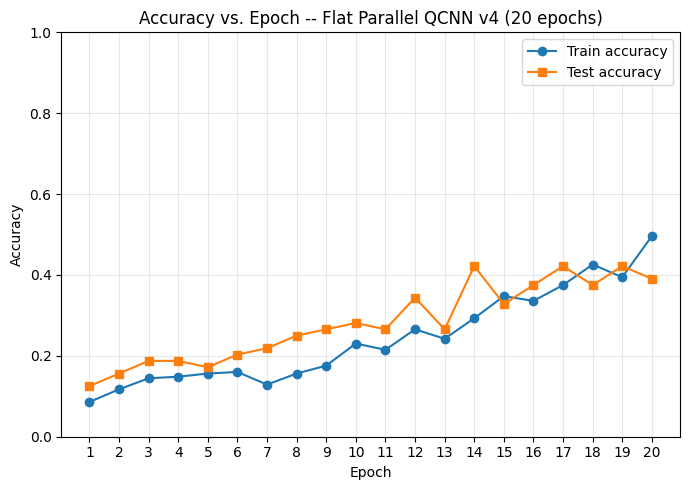

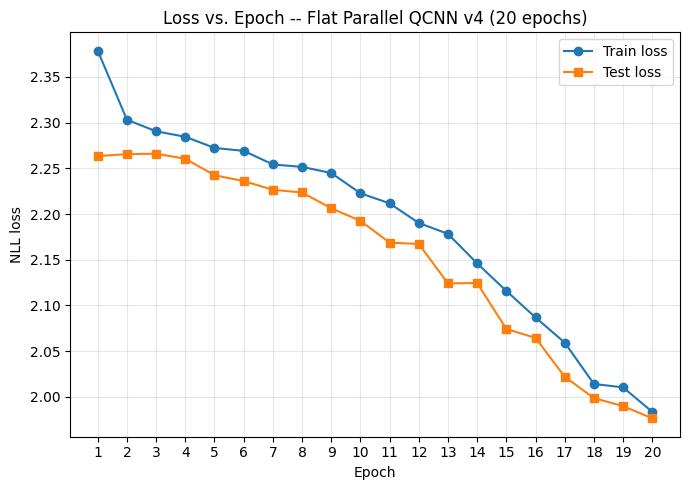

In [ ]:
import matplotlib.pyplot as plt

epochs_axis = list(range(1, N_EPOCHS + 1))

plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_accs, marker='o', label='Train accuracy')
plt.plot(epochs_axis, test_accs,  marker='s', label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title(f'Accuracy vs. Epoch -- Flat Parallel QCNN v4 ({N_EPOCHS} epochs)')
plt.xticks(epochs_axis)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_vs_epoch.png', dpi=150)
plt.show()

# loss vs epoch as well, since it's produced by the same history lists and is
# useful alongside the accuracy curve above
plt.figure(figsize=(7, 5))
plt.plot(epochs_axis, train_losses, marker='o', label='Train loss')
plt.plot(epochs_axis, test_losses,  marker='s', label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('NLL loss')
plt.title(f'Loss vs. Epoch -- Flat Parallel QCNN v4 ({N_EPOCHS} epochs)')
plt.xticks(epochs_axis)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_vs_epoch.png', dpi=150)
plt.show()


## 14. Loss landscape around the trained (post-30-epoch) weights

A 2-D loss-landscape slice through parameter space around the final trained
weights `theta*`, using the standard filter-normalized random-direction
method (Li et al., 2018): pick two random directions `d1`, `d2`, rescale each
parameter tensor's direction to match that tensor's own norm (so no single
layer dominates the step size), then evaluate
`L(alpha, beta) = loss(theta* + alpha*d1 + beta*d2)` over a grid of
`(alpha, beta)` and plot the resulting surface. This visualizes how sharp or
flat the minimum the 20-epoch run converged to actually is -- relevant here
given the barren-plateau concerns that come with the quantum block.

The landscape is evaluated on a single fixed batch (forward pass only, no
backward) since each grid point needs a full model evaluation through the
quantum circuit; model weights are restored to `theta*` afterwards so the
trained model is left untouched. Run Sec. 11 first so `model` holds the
post-20-epoch weights.


In [ ]:
# --- flatten / unflatten helpers ---
def get_flat_params(m):
    return torch.cat([p.data.view(-1) for p in m.parameters()])

def set_flat_params(m, flat):
    idx = 0
    for p in m.parameters():
        n = p.numel()
        p.data.copy_(flat[idx:idx + n].view_as(p))
        idx += n

# snapshot the trained (post-20-epoch) weights
theta_star = get_flat_params(model).clone()
params_list = list(model.parameters())

# two random directions, filter-normalized per parameter tensor so every
# layer's direction is scaled relative to its own weight norm
def random_direction(m):
    return [torch.randn_like(p) for p in m.parameters()]

def filter_normalize(direction, params):
    out = []
    for d, p in zip(direction, params):
        scale = p.data.norm() / (d.norm() + 1e-10)
        out.append(d * scale)
    return out

torch.manual_seed(42)
dir1 = filter_normalize(random_direction(model), params_list)
dir2 = filter_normalize(random_direction(model), params_list)
dir1_flat = torch.cat([d.view(-1) for d in dir1])
dir2_flat = torch.cat([d.view(-1) for d in dir2])

# fixed evaluation batch (quantum forward pass is the expensive part, so keep
# this to one batch rather than the whole dataset)
LANDSCAPE_GRID  = 11      # 11x11 = 121 model evaluations
ALPHA_RANGE     = 1.0     # alpha, beta both range over [-ALPHA_RANGE, ALPHA_RANGE]
xb_land, yb_land = next(iter(train_loader))
xb_land, yb_land = xb_land.to(DEVICE), yb_land.to(DEVICE)

alphas = np.linspace(-ALPHA_RANGE, ALPHA_RANGE, LANDSCAPE_GRID)
betas  = np.linspace(-ALPHA_RANGE, ALPHA_RANGE, LANDSCAPE_GRID)
loss_grid = np.zeros((LANDSCAPE_GRID, LANDSCAPE_GRID))

model.eval()
t0 = time.time()
with torch.no_grad():
    for i, a in enumerate(alphas):
        for j, b in enumerate(betas):
            flat = theta_star + a * dir1_flat + b * dir2_flat
            set_flat_params(model, flat)
            log_probs = model(xb_land)
            loss_grid[i, j] = F.nll_loss(log_probs, yb_land).item()
print(f"loss landscape grid computed in {time.time()-t0:.1f}s "
      f"({LANDSCAPE_GRID**2} model evaluations, batch size {xb_land.shape[0]})")

# restore the trained weights
set_flat_params(model, theta_star)
print("model weights restored to the post-training (theta*) values")


loss landscape grid computed in 41.5s (121 model evaluations, batch size 32)
model weights restored to the post-training (theta*) values


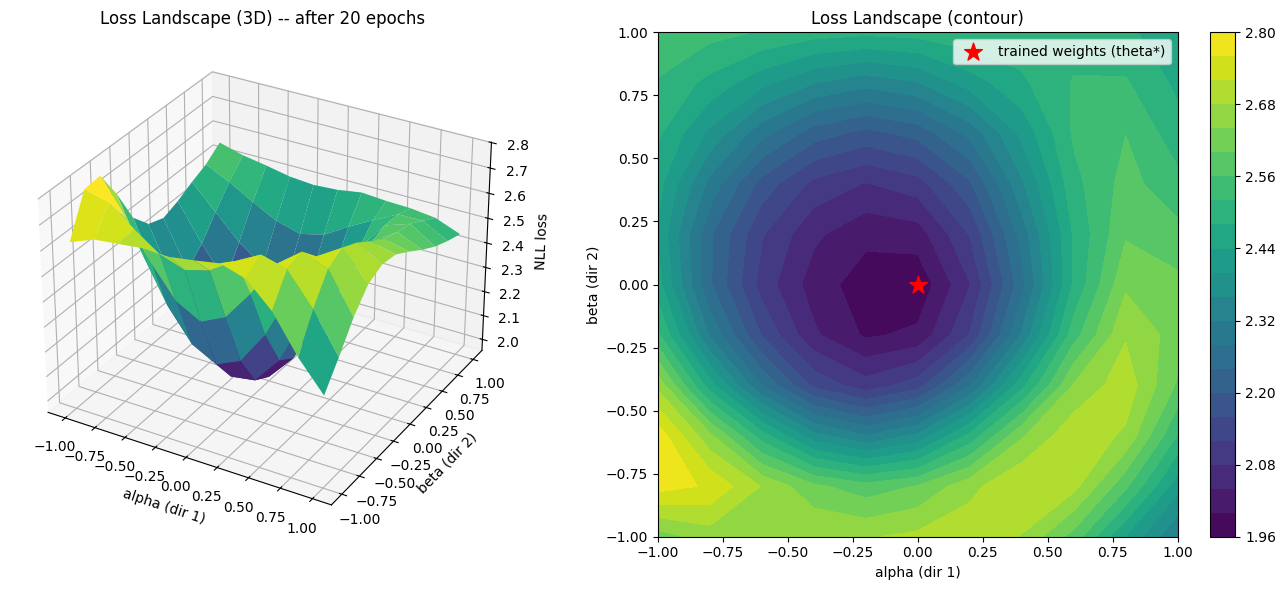

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)

A, B = np.meshgrid(alphas, betas, indexing='ij')

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(A, B, loss_grid, cmap='viridis', edgecolor='none', antialiased=True)
ax1.set_xlabel('alpha (dir 1)')
ax1.set_ylabel('beta (dir 2)')
ax1.set_zlabel('NLL loss')
ax1.set_title(f'Loss Landscape (3D) -- after {N_EPOCHS} epochs')

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(A, B, loss_grid, levels=25, cmap='viridis')
ax2.scatter([0], [0], color='red', marker='*', s=180, label='trained weights (theta*)', zorder=5)
ax2.set_xlabel('alpha (dir 1)')
ax2.set_ylabel('beta (dir 2)')
ax2.set_title('Loss Landscape (contour)')
ax2.legend()
fig.colorbar(cs, ax=ax2)

plt.tight_layout()
plt.savefig('loss_landscape.png', dpi=150)
plt.show()


## 12. Summary of changes vs. v3

**Removed:**
- The classical skip connection (16-d global-average-pooled CNN features
  concatenated before the head).
- The binary-tree reduction across the 64 partitions (`batched_kron`,
  per-level shared conv+pool blocks, `reduction_qnode`/`final_block`,
  `default.mixed`, the vectorized-torch fallback path, and the
  threaded-execution scaffolding -- none of that machinery exists any more).

**Added / changed:**
- `local_block_measure` now measures `PauliZ` directly on the 4 kept qubits
  right after the single conv+pool step, instead of returning a density
  matrix for further processing.
- `QuantumParallelBlock` flattens straight to `(B, 256)` after one
  broadcasted QNode call -- no reduction levels.
- Classifier head is `Linear(256, 10)` on quantum features only (was
  `Linear(20, 10)` on 4 quantum + 16 classical in v3).
- `BATCH_SIZE` raised from 4 to 32.

**Result:** total trainable parameters dropped from v3's 20-features/1-final-block
design to exactly 3,982 (1,368 CNN + 44 quantum + 2,570 classifier), matching
the target parameter budget, and the quantum branch is a single broadcasted
QNode call per batch instead of 1 local + 6 reduction + 1 final = 8 QNode-call
types -- which is also why v4 is dramatically faster per image than v3's
~21s/image (see Sec. 8/9 above).